In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score

In [2]:
data=pd.read_csv("new-thyroid.csv")

In [3]:
import sklearn
sklearn.__version__

'1.0.2'

In [4]:
data.columns=["id","Class","Oxin","Onine","Hormone","Tsh","Resin"]

In [5]:
data.set_index("id", inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 214 entries, 2 to 215
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Class    214 non-null    int64  
 1   Oxin     214 non-null    int64  
 2   Onine    214 non-null    float64
 3   Hormone  214 non-null    float64
 4   Tsh      214 non-null    float64
 5   Resin    214 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 11.7 KB


In [7]:
data

,Class,Oxin,Onine,Hormone,Tsh,Resin
id,,,,,,
2,1,113,9.9,3.1,2.0,5.9
3,1,127,12.9,2.4,1.4,0.6
4,1,109,5.3,1.6,1.4,1.5
5,1,105,7.3,1.5,1.5,-0.1
6,1,105,6.1,2.1,1.4,7.0
...,...,...,...,...,...,...
211,3,118,6.5,1.3,1.7,11.5
212,3,139,4.2,0.7,4.3,6.3
213,3,103,5.1,1.4,1.2,5.0


In [8]:
gb=data.groupby("Class")

In [9]:
for Class, Class_df in gb:
    print(Class)
    print(Class_df)

1
     Class  Oxin  Onine  Hormone  Tsh  Resin
id                                          
2        1   113    9.9      3.1  2.0    5.9
3        1   127   12.9      2.4  1.4    0.6
4        1   109    5.3      1.6  1.4    1.5
5        1   105    7.3      1.5  1.5   -0.1
6        1   105    6.1      2.1  1.4    7.0
..     ...   ...    ...      ...  ...    ...
146      1   126   10.4      1.7  1.2    3.5
147      1   114    7.5      1.1  1.6    4.4
148      1   111   11.9      2.3  0.9    3.8
149      1   104    6.1      1.8  0.5    0.8
150      1   102    6.6      1.2  1.4    1.3

[149 rows x 6 columns]
2
     Class  Oxin  Onine  Hormone  Tsh  Resin
id                                          
151      2   139   16.4      3.8  1.1   -0.2
152      2   111   16.0      2.1  0.9   -0.1
153      2   113   17.2      1.8  1.0    0.0
154      2    65   25.3      5.8  1.3    0.2
155      2    88   24.1      5.5  0.8    0.1
156      2    65   18.2     10.0  1.3    0.1
157      2   134   16.4    

In [10]:
gb.get_group(1)

,Class,Oxin,Onine,Hormone,Tsh,Resin
id,,,,,,
2,1,113,9.9,3.1,2.0,5.9
3,1,127,12.9,2.4,1.4,0.6
4,1,109,5.3,1.6,1.4,1.5
5,1,105,7.3,1.5,1.5,-0.1
6,1,105,6.1,2.1,1.4,7.0
...,...,...,...,...,...,...
146,1,126,10.4,1.7,1.2,3.5
147,1,114,7.5,1.1,1.6,4.4
148,1,111,11.9,2.3,0.9,3.8


In [11]:
class_samples=gb.get_group(1).sample(n=15)
#    print(class_samples)

In [12]:
print(type(class_samples))

<class 'pandas.core.frame.DataFrame'>


In [13]:
mean_sum=class_samples["Oxin"].mean() + class_samples["Onine"].mean() + class_samples["Hormone"].mean() + class_samples["Tsh"].mean() + class_samples["Resin"].mean()

In [14]:
column_length=len(data.columns) -1

In [15]:
similar_val_1=mean_sum/column_length
print(similar_val_1)

24.70933333333333


In [16]:
class_2_samples=gb.get_group(2).sample(n=15)
#    print(class_2_samples)

In [17]:
mean_sum_2=class_2_samples["Oxin"].mean() + class_2_samples["Onine"].mean() + class_2_samples["Hormone"].mean() + class_2_samples["Tsh"].mean() + class_2_samples["Resin"].mean()

In [18]:
similar_val_2=mean_sum_2/column_length
print(similar_val_2)

22.984


In [19]:
class_3_samples=gb.get_group(3).sample(n=15)
#    print(class_3_samples)

In [20]:
mean_sum_3=class_3_samples["Oxin"].mean() + class_3_samples["Onine"].mean() + class_3_samples["Hormone"].mean() + class_3_samples["Tsh"].mean() + class_3_samples["Resin"].mean()

In [21]:
similar_val_3=mean_sum_3/column_length
print(similar_val_3)

31.160000000000004


In [22]:
sim_23=similar_val_3 - similar_val_2
sim_23=sim_23/10
sim_23=1 - sim_23
sim_12=similar_val_1 - similar_val_2
sim_12=sim_12/10
sim_12=1 - sim_12
sim_13=similar_val_3 - similar_val_1
sim_13=sim_13/10
sim_13=1 - sim_13

print("Similarity between 2 and 3: ", sim_23)
print("Similarity between 2 and 1: ", sim_12)
print("Similarity between 1 and 3: ", sim_13)

Similarity between 2 and 3:  0.18239999999999978
Similarity between 2 and 1:  0.8274666666666672
Similarity between 1 and 3:  0.35493333333333266


In [23]:
gb.size()

Class
1    149
2     35
3     30
dtype: int64

In [24]:
m=math.ceil((149+35)/2)

In [25]:
print(m)

92


In [26]:
len(gb)

3

In [27]:
neigh = KNeighborsClassifier(n_neighbors=5)

In [28]:
#neigh.fit(X_train, Y_train)
neigh.fit(data, data.Class)

KNeighborsClassifier()

In [29]:
result=neigh.kneighbors(data, return_distance=True)

In [30]:
print(type(result))

<class 'tuple'>


In [31]:
print(result)

(array([[0.        , 1.33416641, 3.23728281, 3.38821487, 3.47706773],
       [0.        , 3.6796739 , 4.02367991, 4.9979996 , 5.36749476],
       [0.        , 1.72336879, 1.74642492, 2.20454077, 2.48596058],
       ...,
       [0.        , 1.98494332, 2.79284801, 3.33166625, 3.67831483],
       [0.        , 7.80384521, 8.01685724, 8.53580693, 9.41966029],
       [0.        , 1.98494332, 2.83901391, 3.77226722, 4.08166633]]), array([[  0,   6, 122, 126, 118],
       [  1,  41, 144,  72,  37],
       [  2, 129, 137, 138,  88],
       ...,
       [211, 213,  68, 128,   4],
       [212, 213,  92, 128, 143],
       [213, 211, 128,   4,  68]], dtype=int64))


In [32]:
arr1=result[0]

In [33]:
print(type(arr1))

<class 'numpy.ndarray'>


In [34]:
print(arr1.ndim)

2


In [35]:
arr2=result[1]

In [36]:
print(type(arr2))

<class 'numpy.ndarray'>


In [37]:
print(arr1.ndim)

2


In [38]:
print(arr2)

[[  0   6 122 126 118]
 [  1  41 144  72  37]
 [  2 129 137 138  88]
 ...
 [211 213  68 128   4]
 [212 213  92 128 143]
 [213 211 128   4  68]]


In [39]:
print(arr1)

[[0.         1.33416641 3.23728281 3.38821487 3.47706773]
 [0.         3.6796739  4.02367991 4.9979996  5.36749476]
 [0.         1.72336879 1.74642492 2.20454077 2.48596058]
 ...
 [0.         1.98494332 2.79284801 3.33166625 3.67831483]
 [0.         7.80384521 8.01685724 8.53580693 9.41966029]
 [0.         1.98494332 2.83901391 3.77226722 4.08166633]]


In [40]:
#print(arr1)

In [41]:
print(arr1.size)

1070


In [42]:
addVal=[]
s=1
for i in arr1:
    _sum=int(i[0] + i[1] + i[2] + i[3] + i[4])
    addVal.append(_sum)
    print(i ," ", _sum, " ") 
    s=s+1

[0.         1.33416641 3.23728281 3.38821487 3.47706773]   11  
[0.         3.6796739  4.02367991 4.9979996  5.36749476]   18  
[0.         1.72336879 1.74642492 2.20454077 2.48596058]   8  
[0.         1.1        2.04205779 2.08326667 2.16333077]   7  
[0.         3.17647603 3.18590646 3.37194306 3.67831483]   13  
[0.         0.74833148 1.46287388 1.46628783 1.96214169]   5  
[0.         1.33416641 2.37065392 2.54165301 2.64952826]   8  
[0.         1.10905365 1.42126704 1.67332005 1.77200451]   5  
[0.         1.5        2.39374184 2.96479342 3.06757233]   9  
[0.         2.00748599 2.97657521 3.08868904 3.13528308]   11  
[0.         1.26885775 1.43874946 1.46628783 2.34520788]   6  
[0.         1.37840488 1.88148877 1.97737199 2.57487864]   7  
[0.         2.36431808 2.87402157 2.95127091 2.97657521]   11  
[0.         1.56524758 2.22261108 2.39582971 2.50399681]   8  
[0.         1.17046999 1.42126704 2.04450483 2.07846097]   6  
[0.         1.24096736 1.69410743 1.7175564  2.102

In [43]:
print(len(addVal))

214


In [44]:
print(addVal)

[11, 18, 8, 7, 13, 5, 8, 5, 9, 11, 6, 7, 11, 8, 6, 6, 6, 7, 7, 4, 7, 8, 6, 9, 9, 6, 7, 5, 5, 9, 5, 9, 16, 8, 5, 6, 5, 12, 10, 8, 6, 12, 12, 13, 7, 6, 8, 9, 22, 9, 12, 7, 8, 6, 7, 12, 6, 6, 5, 9, 5, 6, 7, 11, 9, 7, 11, 7, 9, 12, 8, 19, 11, 5, 5, 8, 4, 7, 12, 13, 15, 6, 9, 5, 9, 7, 9, 7, 6, 8, 8, 6, 15, 10, 6, 10, 6, 11, 8, 7, 6, 8, 9, 6, 5, 6, 9, 8, 6, 14, 6, 6, 7, 6, 6, 4, 6, 5, 12, 7, 10, 7, 5, 6, 7, 5, 8, 12, 11, 8, 8, 7, 8, 10, 5, 7, 16, 7, 6, 8, 13, 7, 7, 13, 12, 8, 8, 7, 6, 33, 12, 13, 33, 14, 33, 28, 21, 27, 14, 16, 14, 16, 20, 14, 8, 30, 13, 8, 37, 10, 21, 19, 12, 25, 14, 33, 12, 54, 9, 15, 11, 10, 24, 15, 32, 44, 13, 20, 54, 45, 24, 35, 43, 120, 49, 24, 29, 37, 25, 27, 32, 33, 75, 35, 46, 50, 86, 37, 43, 19, 35, 11, 33, 12]


In [45]:
arr3=np.array(addVal)

In [46]:
print(type(arr3))

<class 'numpy.ndarray'>


In [47]:
print(arr3.size)

214


In [48]:
print(arr3)

[ 11  18   8   7  13   5   8   5   9  11   6   7  11   8   6   6   6   7
   7   4   7   8   6   9   9   6   7   5   5   9   5   9  16   8   5   6
   5  12  10   8   6  12  12  13   7   6   8   9  22   9  12   7   8   6
   7  12   6   6   5   9   5   6   7  11   9   7  11   7   9  12   8  19
  11   5   5   8   4   7  12  13  15   6   9   5   9   7   9   7   6   8
   8   6  15  10   6  10   6  11   8   7   6   8   9   6   5   6   9   8
   6  14   6   6   7   6   6   4   6   5  12   7  10   7   5   6   7   5
   8  12  11   8   8   7   8  10   5   7  16   7   6   8  13   7   7  13
  12   8   8   7   6  33  12  13  33  14  33  28  21  27  14  16  14  16
  20  14   8  30  13   8  37  10  21  19  12  25  14  33  12  54   9  15
  11  10  24  15  32  44  13  20  54  45  24  35  43 120  49  24  29  37
  25  27  32  33  75  35  46  50  86  37  43  19  35  11  33  12]


In [49]:
g=1
for i in addVal:
    print(g ," ", i) 
    g=g+1

1   11
2   18
3   8
4   7
5   13
6   5
7   8
8   5
9   9
10   11
11   6
12   7
13   11
14   8
15   6
16   6
17   6
18   7
19   7
20   4
21   7
22   8
23   6
24   9
25   9
26   6
27   7
28   5
29   5
30   9
31   5
32   9
33   16
34   8
35   5
36   6
37   5
38   12
39   10
40   8
41   6
42   12
43   12
44   13
45   7
46   6
47   8
48   9
49   22
50   9
51   12
52   7
53   8
54   6
55   7
56   12
57   6
58   6
59   5
60   9
61   5
62   6
63   7
64   11
65   9
66   7
67   11
68   7
69   9
70   12
71   8
72   19
73   11
74   5
75   5
76   8
77   4
78   7
79   12
80   13
81   15
82   6
83   9
84   5
85   9
86   7
87   9
88   7
89   6
90   8
91   8
92   6
93   15
94   10
95   6
96   10
97   6
98   11
99   8
100   7
101   6
102   8
103   9
104   6
105   5
106   6
107   9
108   8
109   6
110   14
111   6
112   6
113   7
114   6
115   6
116   4
117   6
118   5
119   12
120   7
121   10
122   7
123   5
124   6
125   7
126   5
127   8
128   12
129   11
130   8
131   8
132   7
133   8
134   10
135 

In [50]:
newarr = arr3.reshape(214, 1)

In [51]:
print(newarr.ndim)

2


In [52]:
new_arr2=np.append(arr2, newarr, axis=1)

In [53]:
print(type(new_arr2))

<class 'numpy.ndarray'>


In [54]:
print(new_arr2)

[[  0   6 122 126 118  11]
 [  1  41 144  72  37  18]
 [  2 129 137 138  88   8]
 ...
 [211 213  68 128   4  11]
 [212 213  92 128 143  33]
 [213 211 128   4  68  12]]


In [55]:
print(new_arr2[0])

[  0   6 122 126 118  11]


In [56]:
arr2

array([[  0,   6, 122, 126, 118],
       [  1,  41, 144,  72,  37],
       [  2, 129, 137, 138,  88],
       ...,
       [211, 213,  68, 128,   4],
       [212, 213,  92, 128, 143],
       [213, 211, 128,   4,  68]], dtype=int64)

In [57]:
print(new_arr2[0][1],  new_arr2[0][2],  new_arr2[0][3], new_arr2[0][4],new_arr2[0][5])

6 122 126 118 11


In [58]:
# Creating and populating a dictionary
new_dist={}
for i, v in data.Class.iteritems():
    new_dist[i]=v

In [59]:
print(new_dist)

{2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 1, 128: 1, 129: 1, 130: 1, 131: 1, 132: 1, 133: 1, 134: 1, 135: 1, 136: 1, 137: 1, 138: 1, 139: 1, 1

In [60]:
# Creating and populating a dictionary
new_dist2={}
s=0
for i, v in data.Class.iteritems():
    new_dist2[s]=v
    s=s+1

In [61]:
print(new_dist2)

{0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 1, 128: 1, 129: 1, 130: 1, 131: 1, 132: 1, 133: 1, 134: 1, 135: 1, 136: 1, 137: 1, 138: 

In [62]:
# Creating and populating a dictionary
new_dist3={}
s=0
for i, v in data.Class.iteritems():
    new_dist3[s]=i
    s=s+1

In [63]:
print(new_dist3)

{0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8, 7: 9, 8: 10, 9: 11, 10: 12, 11: 13, 12: 14, 13: 15, 14: 16, 15: 17, 16: 18, 17: 19, 18: 20, 19: 21, 20: 22, 21: 23, 22: 24, 23: 25, 24: 26, 25: 27, 26: 28, 27: 29, 28: 30, 29: 31, 30: 32, 31: 33, 32: 34, 33: 35, 34: 36, 35: 37, 36: 38, 37: 39, 38: 40, 39: 41, 40: 42, 41: 43, 42: 44, 43: 45, 44: 46, 45: 47, 46: 48, 47: 49, 48: 50, 49: 51, 50: 52, 51: 53, 52: 54, 53: 55, 54: 56, 55: 57, 56: 58, 57: 59, 58: 60, 59: 61, 60: 62, 61: 63, 62: 64, 63: 65, 64: 66, 65: 67, 66: 68, 67: 69, 68: 70, 69: 71, 70: 72, 71: 73, 72: 74, 73: 75, 74: 76, 75: 77, 76: 78, 77: 79, 78: 80, 79: 81, 80: 82, 81: 83, 82: 84, 83: 85, 84: 86, 85: 87, 86: 88, 87: 89, 88: 90, 89: 91, 90: 92, 91: 93, 92: 94, 93: 95, 94: 96, 95: 97, 96: 98, 97: 99, 98: 100, 99: 101, 100: 102, 101: 103, 102: 104, 103: 105, 104: 106, 105: 107, 106: 108, 107: 109, 108: 110, 109: 111, 110: 112, 111: 113, 112: 114, 113: 115, 114: 116, 115: 117, 116: 118, 117: 119, 118: 120, 119: 121, 120: 122, 121: 

In [64]:
#print(new_dist[204])

<!-- Populating a dictionary  -->

In [65]:
    neigh_count=[]
    s=0
    for i, v in new_dist2.items():
        c1=0
        c2=0
        c3=0
        class_example=0
        if int(v) == 1:
            c1=c1+1
        elif int(v) == 2:
            c2=c2+1
        else:
            c3=c3+1
        for x in range(1,5):
            if new_dist2[new_arr2[i][x]]==1:
                c1=c1+1
            elif new_dist2[new_arr2[i][x]]==2:
                c2=c2+1
            else:
                c3=c3+1
            if int(v) == 1:
                safe_level=(1 * c1 + sim_12 * c2 + sim_13 * c3)/5
                class_example=1
                safe_level=round(safe_level,2)
            elif int(v) == 2:
                safe_level=(sim_12 * c1 + 1 * c2 + sim_23 * c3)/5
                class_example=2
                safe_level=round(safe_level,2)
            else:
                safe_level=(sim_13 * c1 + sim_23 * c2 + 1 * c3)/5
                class_example=3
                safe_level=round(safe_level,2)
        neigh_count.append([i,new_dist3[i],class_example,c1,c2,c3,safe_level,new_arr2[i][5]])
        #print(i," ",new_dist3[i]," ",class_example," ",c1," ",c2," ",c3," ",safe_level," ",new_arr2[i][5])
        #print(i," ",new_dist3[i]," ",c1," ",c2," ",c3," ",new_arr2[i][5])
    #real_new=new_dist3[i]," ",new_arr2[i][1]," ",new_arr2[i][2]," ",new_arr2[i][3]," ",new_arr2[i][4]," ",new_arr2[i][5]
    
    #print(i," ",real_new)

In [66]:
#print(neigh_count)

In [67]:
# iterating a dictionary

In [68]:
# for s in range(149):
#     print(neigh_count[s])

In [69]:
# Converting a dictionary to a dataframe

In [70]:
new_main_df = pd.DataFrame(neigh_count,columns=['s_no','real_index','Class','c_one','c_two','c_three','safe_level','distance'])

In [71]:
#print(new_main_df)

In [72]:
new_main_df.set_index("s_no", inplace=True)

In [73]:
print(new_main_df)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
0              2      1      5      0        0        1.00        11
1              3      1      5      0        0        1.00        18
2              4      1      5      0        0        1.00         8
3              5      1      5      0        0        1.00         7
4              6      1      4      0        1        0.87        13
...          ...    ...    ...    ...      ...         ...       ...
209          211      3      3      0        2        0.61        19
210          212      3      1      0        4        0.87        35
211          213      3      3      0        2        0.61        11
212          214      3      3      0        2        0.61        33
213          215      3      3      0        2        0.61        12

[214 rows x 7 columns]


In [74]:
# iterating through a dataframe, the following methods can be used .iterrows() 
# and itertuples() but itertuples is preferred because it keeps the data types and more

In [75]:
# for index, row in new_main_df.iterrows():
#     print(index, row['real_index'], row['class'], row['c_one'], row['c_two'], row['c_three'], row['safe_level'], row['distance'] )

In [76]:
for i, row in enumerate(new_main_df.itertuples(), 0):
    print(i, row.real_index)
    

0 2
1 3
2 4
3 5
4 6
5 7
6 8
7 9
8 10
9 11
10 12
11 13
12 14
13 15
14 16
15 17
16 18
17 19
18 20
19 21
20 22
21 23
22 24
23 25
24 26
25 27
26 28
27 29
28 30
29 31
30 32
31 33
32 34
33 35
34 36
35 37
36 38
37 39
38 40
39 41
40 42
41 43
42 44
43 45
44 46
45 47
46 48
47 49
48 50
49 51
50 52
51 53
52 54
53 55
54 56
55 57
56 58
57 59
58 60
59 61
60 62
61 63
62 64
63 65
64 66
65 67
66 68
67 69
68 70
69 71
70 72
71 73
72 74
73 75
74 76
75 77
76 78
77 79
78 80
79 81
80 82
81 83
82 84
83 85
84 86
85 87
86 88
87 89
88 90
89 91
90 92
91 93
92 94
93 95
94 96
95 97
96 98
97 99
98 100
99 101
100 102
101 103
102 104
103 105
104 106
105 107
106 108
107 109
108 110
109 111
110 112
111 113
112 114
113 115
114 116
115 117
116 118
117 119
118 120
119 121
120 122
121 123
122 124
123 125
124 126
125 127
126 128
127 129
128 130
129 131
130 132
131 133
132 134
133 135
134 136
135 137
136 138
137 139
138 140
139 141
140 142
141 143
142 144
143 145
144 146
145 147
146 148
147 149
148 150
149 151
150 152
151 153


In [77]:
new_classes=new_main_df.groupby("Class")

In [78]:
new_classes.size()

Class
1    149
2     35
3     30
dtype: int64

In [79]:
new_class_1=new_classes.get_group(1)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_1.itertuples(index=True), 0):
    if(row.c_one==5 or row.c_one==4):
        safe_exam=safe_exam + 1
    elif(row.c_one==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_one==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

147 2 0 0


In [80]:
new_class_2=new_classes.get_group(2)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_2.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_two==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

25 10 0 0


In [81]:
new_class_3=new_classes.get_group(3)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_3.itertuples(index=True), 0):
    if(row.c_three==5 or row.c_three==4):
        safe_exam=safe_exam + 1
    elif(row.c_three==3 or row.c_three==2):
        border_exam=border_exam + 1
    elif(row.c_three==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

23 5 2 0


In [82]:
# for row in new_main_df.itertuples():
#     print(getattr(row, 'real_index'), getattr(row, 'c_one'))

In [83]:
new_gb=new_main_df.groupby("Class")

In [84]:
new_1=new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [85]:
new_1

,real_index,Class,c_one,c_two,c_three,safe_level,distance
s_no,,,,,,,
71,73,1,5,0,0,1.00,19
1,3,1,5,0,0,1.00,18
136,138,1,5,0,0,1.00,16
80,82,1,5,0,0,1.00,15
92,94,1,5,0,0,1.00,15
...,...,...,...,...,...,...,...
4,6,1,4,0,1,0.87,13
9,11,1,4,0,1,0.87,11
128,130,1,4,0,1,0.87,11


In [86]:
#new_2=new_gb.get_group(2)

In [87]:
#new_3=new_gb.get_group(3)

In [88]:
gb_1=gb.get_group(1)

In [89]:
gb_2=gb.get_group(2)

In [90]:
gb_3=gb.get_group(3)

In [91]:
#new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [92]:
new_2=new_gb.get_group(2).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [93]:
#new_2

In [94]:
#for dropping some index with less simlar neigbour
#new_2.drop(new_2[new_2['c_two'] < 4].index, inplace=True)

In [95]:
#new_2

In [96]:
#b=len(new_2.index)

In [97]:
#print(b)

In [98]:
#s=m - b

In [99]:
#print(s)

In [100]:
#if(s>b):
    #minor_c_2=new_2.sample(n=b, replace='False')
    #print(len(minor_c_2.index))
    #minor_c_2=minor_c_2.sample(n=b, replace='True')
    #print(len(minor_c_2.index))

In [101]:
#u=len(minor_c_2.index)

In [102]:
#print(u)

In [103]:
minor_c_2=new_2.sample(n=m, replace='True')
print(minor_c_2)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
179          181      2      0      5        0        1.00        15
179          181      2      0      5        0        1.00        15
175          177      2      0      5        0        1.00        33
155          157      2      3      2        0        0.90        28
175          177      2      0      5        0        1.00        33
...          ...    ...    ...    ...      ...         ...       ...
162          164      2      2      3        0        0.93        20
163          165      2      0      5        0        1.00        14
174          176      2      0      5        0        1.00        14
157          159      2      0      5        0        1.00        27
157          159      2      0      5        0        1.00        27

[92 rows x 7 columns]


In [104]:
new_3=new_gb.get_group(3).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [105]:
#for dropping some index with less simlar neigbour
#new_3.drop(new_3[new_3['c_three'] < 4].index, inplace=True)

In [106]:
minor_c_3=new_3.sample(n=m, replace='True')
print(minor_c_3)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
212          214      3      3      0        2        0.61        33
209          211      3      3      0        2        0.61        19
200          202      3      0      0        5        1.00        32
195          197      3      2      0        3        0.74        24
197          199      3      0      0        5        1.00        37
...          ...    ...    ...    ...      ...         ...       ...
212          214      3      3      0        2        0.61        33
187          189      3      4      0        1        0.48        20
206          208      3      0      0        5        1.00        86
206          208      3      0      0        5        1.00        86
206          208      3      0      0        5        1.00        86

[92 rows x 7 columns]


In [107]:
new_gb

In [108]:
gb

In [109]:
#new_1

In [110]:
new_1.drop(new_1[new_1['c_one'] < 5].index, inplace=True)

In [111]:
#new_1

In [112]:
#for i, row in enumerate(new_1.itertuples(index=True), 0):
    #print(i, row.Index, row.real_index, row.Class, row.c_one, row.c_two, row.c_three, row.safe_level, row.distance)

In [113]:
#r=len(new_1.index)-m

In [114]:
#print(r)

In [115]:
major_c_1=new_1.sample(n=m)
print(major_c_1)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
11            13      1      5      0        0         1.0         7
92            94      1      5      0        0         1.0        15
66            68      1      5      0        0         1.0        11
83            85      1      5      0        0         1.0         5
62            64      1      5      0        0         1.0         7
...          ...    ...    ...    ...      ...         ...       ...
85            87      1      5      0        0         1.0         7
76            78      1      5      0        0         1.0         4
18            20      1      5      0        0         1.0         7
141          143      1      5      0        0         1.0         7
80            82      1      5      0        0         1.0        15

[92 rows x 7 columns]


In [116]:
#for i, row in enumerate(major_c_1.itertuples(index=True), 0):
    #print(i, row.real_index)

In [117]:
#how to generate a random list from an interval
#num_list = random.sample(range(0, len(new_1.index)), r)
#print(num_list)

In [118]:
maj_c_filtered=[]
for i, row in enumerate(major_c_1.itertuples(index=True), 0):
    a=gb_1.at[row.real_index, 'Class']
    b=gb_1.at[row.real_index, 'Oxin']
    c=gb_1.at[row.real_index, 'Onine']
    d=gb_1.at[row.real_index, 'Hormone']
    e=gb_1.at[row.real_index, 'Tsh']
    f=gb_1.at[row.real_index, 'Resin']
    maj_c_filtered.append([a,b,c,d,e,f])

In [119]:
print(maj_c_filtered)

[[1, 116, 9.2, 2.7, 1.0, 4.2], [1, 98, 8.6, 1.6, 1.6, 6.0], [1, 97, 7.8, 1.3, 1.2, 0.9], [1, 111, 7.8, 2.0, 1.8, 4.1], [1, 116, 10.0, 1.7, 1.5, 4.3], [1, 94, 7.5, 1.2, 1.3, 4.4], [1, 105, 11.1, 2.0, 1.0, 1.0], [1, 110, 8.4, 1.4, 1.0, 1.9], [1, 133, 9.7, 2.9, 0.8, 1.9], [1, 115, 8.1, 1.7, 0.6, 2.2], [1, 113, 11.5, 1.5, 1.9, 2.9], [1, 117, 9.2, 1.9, 1.5, 6.8], [1, 115, 10.4, 1.8, 1.6, 2.0], [1, 119, 10.6, 2.1, 1.3, 1.1], [1, 103, 8.1, 1.4, 0.5, 3.8], [1, 100, 9.5, 2.5, 1.3, -0.2], [1, 120, 10.4, 2.1, 1.1, 1.8], [1, 108, 7.1, 1.3, 1.6, 2.2], [1, 98, 9.1, 1.4, 1.9, -0.3], [1, 110, 7.8, 1.9, 2.1, 6.4], [1, 122, 9.7, 1.6, 0.9, 2.2], [1, 123, 8.1, 2.3, 1.0, 5.1], [1, 116, 10.1, 2.2, 1.6, 0.8], [1, 117, 11.0, 1.4, 1.5, 2.1], [1, 104, 9.6, 1.1, 1.3, 0.8], [1, 112, 10.6, 1.6, 0.9, -0.1], [1, 101, 7.8, 1.2, 1.0, 1.7], [1, 111, 9.1, 1.7, 1.2, 4.1], [1, 106, 9.4, 2.2, 1.5, 0.0], [1, 118, 12.2, 1.5, 1.0, 2.3], [1, 114, 8.4, 1.6, 1.6, -0.2], [1, 114, 7.5, 1.1, 1.6, 4.4], [1, 120, 8.4, 1.1, 1.4, 1.4],

In [120]:
#for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    #print(i, row.real_index)

In [121]:
min_c_2_filtered=[]
for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    a=gb_2.at[row.real_index, 'Class']
    b=gb_2.at[row.real_index, 'Oxin']
    c=gb_2.at[row.real_index, 'Onine']
    d=gb_2.at[row.real_index, 'Hormone']
    e=gb_2.at[row.real_index, 'Tsh']
    f=gb_2.at[row.real_index, 'Resin']
    min_c_2_filtered.append([a,b,c,d,e,f])

In [122]:
print(min_c_2_filtered)

[[2, 88, 16.5, 4.9, 0.8, 0.1], [2, 88, 16.5, 4.9, 0.8, 0.1], [2, 76, 25.3, 4.5, 1.2, -0.1], [2, 134, 16.4, 4.8, 0.6, 0.1], [2, 76, 25.3, 4.5, 1.2, -0.1], [2, 144, 22.3, 3.3, 1.3, 0.6], [2, 110, 20.3, 3.7, 0.6, 0.2], [2, 68, 14.7, 7.8, 0.6, -0.2], [2, 84, 18.5, 4.4, 1.1, -0.3], [2, 79, 19.0, 5.5, 0.9, 0.3], [2, 67, 23.3, 7.4, 1.8, -0.6], [2, 111, 16.0, 2.1, 0.9, -0.1], [2, 84, 21.5, 2.7, 1.1, -0.6], [2, 76, 25.3, 4.5, 1.2, -0.1], [2, 94, 20.5, 1.8, 1.4, -0.5], [2, 105, 12.0, 3.3, 1.1, 0.0], [2, 99, 17.5, 1.9, 1.4, 0.3], [2, 76, 25.3, 4.5, 1.2, -0.1], [2, 99, 13.0, 3.1, 0.5, -0.1], [2, 84, 18.5, 4.4, 1.1, -0.3], [2, 110, 20.3, 3.7, 0.6, 0.2], [2, 67, 23.3, 7.4, 1.8, -0.6], [2, 89, 20.1, 7.3, 1.1, -0.2], [2, 89, 20.1, 7.3, 1.1, -0.2], [2, 84, 18.5, 4.4, 1.1, -0.3], [2, 95, 11.1, 2.7, 1.6, -0.3], [2, 94, 20.5, 1.8, 1.4, -0.5], [2, 99, 13.0, 3.1, 0.5, -0.1], [2, 97, 14.2, 3.6, 1.5, 0.3], [2, 88, 24.1, 5.5, 0.8, 0.1], [2, 89, 14.3, 4.1, 0.5, 0.2], [2, 89, 14.3, 4.1, 0.5, 0.2], [2, 99, 13.0, 

In [123]:
#for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    #print(i, row.real_index)

In [124]:
min_c_3_filtered=[]
for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    a=gb_3.at[row.real_index, 'Class']
    b=gb_3.at[row.real_index, 'Oxin']
    c=gb_3.at[row.real_index, 'Onine']
    d=gb_3.at[row.real_index, 'Hormone']
    e=gb_3.at[row.real_index, 'Tsh']
    f=gb_3.at[row.real_index, 'Resin']
    min_c_3_filtered.append([a,b,c,d,e,f])

In [125]:
print(min_c_3_filtered)

[[3, 97, 4.7, 1.1, 2.1, 12.6], [3, 118, 6.5, 1.3, 1.7, 11.5], [3, 141, 2.5, 1.3, 8.5, 7.5], [3, 115, 6.3, 1.2, 4.7, 14.4], [3, 121, 4.7, 1.8, 11.2, 53.0], [3, 134, 1.9, 0.6, 18.4, 8.2], [3, 141, 5.6, 1.8, 9.2, 14.4], [3, 125, 2.3, 0.9, 16.5, 9.5], [3, 115, 6.3, 1.2, 4.7, 14.4], [3, 120, 6.8, 2.1, 10.4, 38.6], [3, 126, 0.5, 0.2, 12.2, 8.8], [3, 121, 4.7, 1.8, 11.2, 53.0], [3, 102, 5.3, 1.4, 1.3, 6.7], [3, 125, 3.7, 1.1, 8.5, 25.9], [3, 108, 3.5, 0.6, 1.7, 1.4], [3, 141, 5.6, 1.8, 9.2, 14.4], [3, 115, 6.3, 1.2, 4.7, 14.4], [3, 131, 2.7, 0.8, 9.9, 4.7], [3, 118, 3.6, 1.5, 11.6, 48.8], [3, 123, 5.6, 1.1, 13.7, 56.3], [3, 115, 6.3, 1.2, 4.7, 14.4], [3, 134, 2.0, 0.5, 12.2, 2.2], [3, 97, 4.7, 1.1, 2.1, 12.6], [3, 134, 2.0, 0.5, 12.2, 2.2], [3, 118, 3.6, 1.5, 11.6, 48.8], [3, 102, 5.3, 1.4, 1.3, 6.7], [3, 97, 4.7, 1.1, 2.1, 12.6], [3, 123, 1.9, 0.3, 22.8, 22.2], [3, 123, 1.9, 0.3, 22.8, 22.2], [3, 129, 1.5, 0.6, 12.5, 2.9], [3, 113, 5.1, 0.7, 5.8, 19.6], [3, 119, 0.8, 0.7, 56.4, 21.6], [3, 97

In [126]:
new_min_c_3_filtered = pd.DataFrame(min_c_3_filtered,columns=['Class','Oxin','Onine','Hormone','Tsh','Resin'])

In [127]:
print(new_min_c_3_filtered)

    Class  Oxin  Onine  Hormone   Tsh  Resin
0       3    97    4.7      1.1   2.1   12.6
1       3   118    6.5      1.3   1.7   11.5
2       3   141    2.5      1.3   8.5    7.5
3       3   115    6.3      1.2   4.7   14.4
4       3   121    4.7      1.8  11.2   53.0
..    ...   ...    ...      ...   ...    ...
87      3    97    4.7      1.1   2.1   12.6
88      3   120    3.0      2.5   1.2    4.5
89      3   112    2.6      0.7  41.0   19.0
90      3   112    2.6      0.7  41.0   19.0
91      3   112    2.6      0.7  41.0   19.0

[92 rows x 6 columns]


In [128]:
new_min_c_2_filtered = pd.DataFrame(min_c_2_filtered,columns=['Class','Oxin','Onine','Hormone','Tsh','Resin'])

In [129]:
print(new_min_c_2_filtered)

    Class  Oxin  Onine  Hormone  Tsh  Resin
0       2    88   16.5      4.9  0.8    0.1
1       2    88   16.5      4.9  0.8    0.1
2       2    76   25.3      4.5  1.2   -0.1
3       2   134   16.4      4.8  0.6    0.1
4       2    76   25.3      4.5  1.2   -0.1
..    ...   ...    ...      ...  ...    ...
87      2   105   17.4      1.6  0.3    0.4
88      2    89   20.1      7.3  1.1   -0.2
89      2    99   17.5      1.9  1.4    0.3
90      2    67   23.3      7.4  1.8   -0.6
91      2    67   23.3      7.4  1.8   -0.6

[92 rows x 6 columns]


In [130]:
new_maj_c_filtered = pd.DataFrame(maj_c_filtered,columns=['Class','Oxin','Onine','Hormone','Tsh','Resin'])

In [131]:
print(new_maj_c_filtered)

    Class  Oxin  Onine  Hormone  Tsh  Resin
0       1   116    9.2      2.7  1.0    4.2
1       1    98    8.6      1.6  1.6    6.0
2       1    97    7.8      1.3  1.2    0.9
3       1   111    7.8      2.0  1.8    4.1
4       1   116   10.0      1.7  1.5    4.3
..    ...   ...    ...      ...  ...    ...
87      1   119   11.4      2.3  2.2    1.6
88      1   101    7.1      1.6  1.5    1.6
89      1   115    7.1      1.3  1.3    2.0
90      1   112    6.5      1.2  1.2    2.0
91      1    91    8.0      1.7  2.1    4.6

[92 rows x 6 columns]


In [132]:
result = new_maj_c_filtered.append([new_min_c_2_filtered, new_min_c_3_filtered], ignore_index='True')

In [133]:
print(result)

     Class  Oxin  Onine  Hormone   Tsh  Resin
0        1   116    9.2      2.7   1.0    4.2
1        1    98    8.6      1.6   1.6    6.0
2        1    97    7.8      1.3   1.2    0.9
3        1   111    7.8      2.0   1.8    4.1
4        1   116   10.0      1.7   1.5    4.3
..     ...   ...    ...      ...   ...    ...
271      3    97    4.7      1.1   2.1   12.6
272      3   120    3.0      2.5   1.2    4.5
273      3   112    2.6      0.7  41.0   19.0
274      3   112    2.6      0.7  41.0   19.0
275      3   112    2.6      0.7  41.0   19.0

[276 rows x 6 columns]


In [134]:
result.to_csv("balanced_new_thyroid.csv")

In [135]:
result=result.sample(frac=1).reset_index(drop=True)

In [136]:
result.to_csv("balanced_new_thyroid_rand.csv")

In [137]:
X_train, X_test, Y_train, Y_test = train_test_split(result, result.Class, train_size=.7)

In [138]:
X_test

,Class,Oxin,Onine,Hormone,Tsh,Resin
189,2,80,23.0,10.0,0.9,-0.1
111,3,134,2.0,0.5,12.2,2.2
54,2,76,25.3,4.5,1.2,-0.1
262,2,144,22.3,3.3,1.3,0.6
176,3,119,5.1,1.1,7.0,40.8
...,...,...,...,...,...,...
113,3,118,3.6,1.5,11.6,48.8
133,2,84,18.5,4.4,1.1,-0.3
65,2,89,23.8,5.4,0.5,0.1
270,2,139,16.4,3.8,1.1,-0.2


In [139]:
Y_test

189    2
111    3
54     2
262    2
176    3
      ..
113    3
133    2
65     2
270    2
30     3
Name: Class, Length: 83, dtype: int64

In [140]:
categories=result.groupby("Class")

In [141]:
w=categories.size()
cat_index=[]
cat_value=[]
d=0
for index, value in w.items():
    cat_index.append(float(index))
    cat_value.append(float(value))
    d=d+1

In [142]:
w1=gb.size()
cat_index1=[]
cat_value1=[]
d1=0
for index1, value1 in w1.items():
    cat_index1.append(float(index1))
    cat_value1.append(float(value1))
    d1=d1+1

In [143]:
print(w)

Class
1    92
2    92
3    92
dtype: int64


In [144]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=4)
knn = KNeighborsClassifier(n_neighbors=5)

In [145]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [146]:
#model_pred_proba=model.predict_proba(X_test)[:,1]
#clf_pred_proba=clf.predict_proba(X_test)[:,1]
#knn_pred_proba=knn.predict_proba(X_test)[:,1]
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [147]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [148]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))


Accuracy for SVM Test Data:                         0.8433734939759037
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         0.963855421686747


In [149]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [150]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            0.882997737868316
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            0.9733244152393666


In [151]:
cm_model_test=confusion_matrix(Y_test, model_X_test_pred)

In [152]:
cm_model_test

array([[27,  0,  0],
       [ 5, 21,  0],
       [ 8,  0, 22]], dtype=int64)

In [153]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=model.classes_)

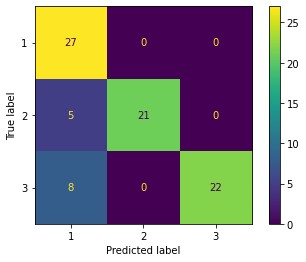

In [154]:
disp_model.plot() 

In [155]:
cm_clf_test=confusion_matrix(Y_test, clf_X_test_pred)

In [156]:
cm_clf_test

array([[27,  0,  0],
       [ 0, 26,  0],
       [ 0,  0, 30]], dtype=int64)

In [157]:
disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test, display_labels=model.classes_)

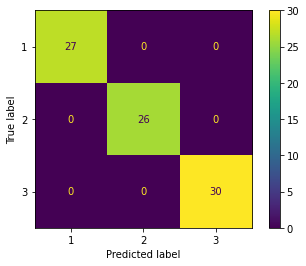

In [158]:
disp_clf.plot() 

In [159]:
cm_knn_test=confusion_matrix(Y_test, knn_X_test_pred)

In [160]:
cm_knn_test

array([[26,  1,  0],
       [ 0, 26,  0],
       [ 2,  0, 28]], dtype=int64)

In [161]:
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn_test, display_labels=model.classes_)

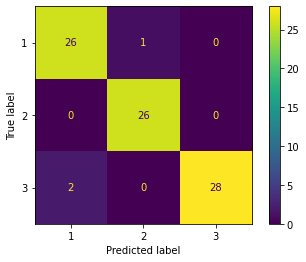

In [162]:
disp_knn.plot()

In [163]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000        27
           2      1.000     1.000     1.000        26
           3      1.000     1.000     1.000        30

    accuracy                          1.000        83
   macro avg      1.000     1.000     1.000        83
weighted avg      1.000     1.000     1.000        83



In [164]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.929     0.963     0.945        27
           2      0.963     1.000     0.981        26
           3      1.000     0.933     0.966        30

    accuracy                          0.964        83
   macro avg      0.964     0.965     0.964        83
weighted avg      0.965     0.964     0.964        83



In [165]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.675     1.000     0.806        27
           2      1.000     0.808     0.894        26
           3      1.000     0.733     0.846        30

    accuracy                          0.843        83
   macro avg      0.892     0.847     0.849        83
weighted avg      0.894     0.843     0.848        83



In [166]:
#model_cvp=cross_val_predict(model, X_test, Y_test, cv=3, method="predict")

In [167]:
#roc_auc_score(Y_test, model_pred_proba, multi_class='ovr')